<a href="https://colab.research.google.com/github/alanantony444/ict-assignment/blob/main/assingment_3__classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question 1**

# Understand and Explore the Dataset
• Load the dataset and inspect its structure.

• Identify numerical and categorical features.

• Analyze the distribution of the target variable y.




In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# **Load data set**

In [5]:
df = pd.read_csv("/content/bank-additional-full.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47387 entries, 0 to 47386
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             47386 non-null  float64
 1   job             47387 non-null  object 
 2   marital         47387 non-null  object 
 3   education       47387 non-null  object 
 4   default         47387 non-null  object 
 5   housing         47387 non-null  object 
 6   loan            47387 non-null  object 
 7   contact         47387 non-null  object 
 8   month           47386 non-null  object 
 9   day_of_week     47386 non-null  object 
 10  duration        47386 non-null  float64
 11  campaign        47386 non-null  float64
 12  pdays           47386 non-null  float64
 13  previous        47386 non-null  object 
 14  poutcome        47386 non-null  object 
 15  emp.var.rate    47386 non-null  float64
 16  cons.price.idx  47386 non-null  float64
 17  cons.conf.idx   47386 non-null 

/tmp/ipykernel_14043/1840525712.py:1: DtypeWarning: Columns (13,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/bank-additional-full.csv")


,age,duration,campaign,pdays,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m
count,47386.000000,47386.000000,47386.000000,47386.000000,47386.000000,47386.000000,47386.000000,47386.000000
mean,40.214578,260.228063,2.493775,939.927447,-0.230442,93.512716,-40.162564,3.379313
std,11.138979,258.319640,2.649711,234.883727,1.749623,0.893685,5.035019,23.482586
min,17.000000,0.000000,1.000000,0.000000,-3.400000,-46.200000,-50.800000,0.634000
25%,32.000000,104.000000,1.000000,999.000000,-1.800000,92.963000,-42.700000,1.266000
50%,38.000000,182.000000,2.000000,999.000000,1.100000,93.444000,-41.800000,4.855000
75%,47.000000,323.000000,3.000000,999.000000,1.400000,93.994000,-36.400000,4.960000
max,98.000000,4918.000000,56.000000,999.000000,92.893000,94.767000,1.250000,5099.100000


**identify numericals**

In [6]:
# Categorical and Numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns
print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'previous', 'poutcome', 'nr.employed', 'y'],
      dtype='object')
Numerical: Index(['age', 'duration', 'campaign', 'pdays', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m'],
      dtype='object')


**Analysing**

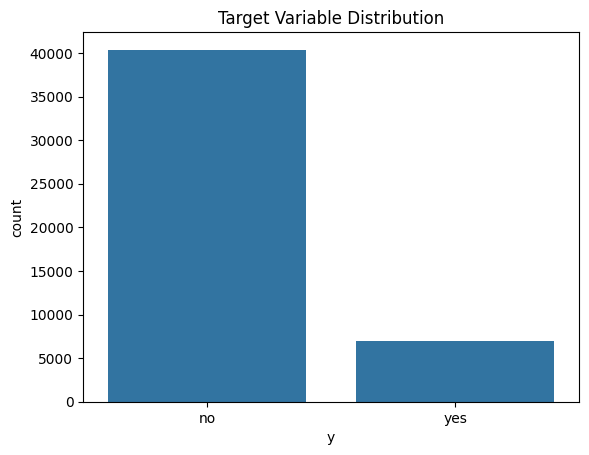

In [7]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

# **Question 2**

#  Data Preprocessing
• Handle missing or unknown values using suitable techniques.

• Encode categorical variables using appropriate encoding methods.

• Scale numerical features where required.

• Split the dataset into training and testing sets.


# Handling

In [8]:
df.replace('unknown', np.nan, inplace=True)
df.dropna(inplace=True)

#  Encode categorical variables

In [13]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# Future scaling

In [14]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

#  training and testing sets

In [15]:
X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply Classification Models
Build and evaluate the following individual machine learning models:

• Logistic Regression

• K-Nearest Neighbors (kNN)

• Support Vector Machine (SVM)

• Decision Tree Classifier


# **✔ Logistic Regression**

In [16]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# **K-Nearest Neighbors kNN**

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# **Support Vector Machine (SVM)**

In [18]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# **Decision tree**

In [19]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# **Question 4**


#  Apply Ensemble Learning Methods
• Random Forest

• Boosting models (Gradient Boosting/XGBoost)

# Random forest

In [20]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Boosting models

In [21]:
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# **Question 5**

#  Model EvaluationN
Evaluate all models using the following metrics:

• Accuracy

• Precision

• Recall

• F1-score

Compare the performance of:

• Individual models vs Ensemble models

In [22]:
# Model Evaluation
def evaluate(y_test, y_pred, model_name):
    print(f"\n {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

In [23]:
# Evaluvate all models
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_knn, "KNN")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")


 Logistic Regression
Accuracy: 0.8774714564188248
Precision: 0.6602409638554216
Recall: 0.4781849912739965
F1 Score: 0.5546558704453441

 KNN
Accuracy: 0.8859649122807017
Precision: 0.6737513283740701
Recall: 0.5532286212914486
F1 Score: 0.6075706756109248

 SVM
Accuracy: 0.8760790866054023
Precision: 0.6823361823361823
Recall: 0.4179755671902269
F1 Score: 0.5183982683982684

 Decision Tree
Accuracy: 0.9227234753550543
Precision: 0.7532133676092545
Recall: 0.7670157068062827
F1 Score: 0.7600518806744487

 Random Forest
Accuracy: 0.943052074631022
Precision: 0.8688688688688688
Recall: 0.7574171029668412
F1 Score: 0.8093240093240093

 Gradient Boosting
Accuracy: 0.883876357560568
Precision: 0.65
Recall: 0.5898778359511344
F1 Score: 0.6184812442817932


# **Question 6**

# Model Selection and Interpretation
• Identify the best-performing model.

• Justify your choice based on evaluation metrics.

• Explain which features influence customer subscription the most.

• Provide business insights on how the bank can improve marketing
campaigns.

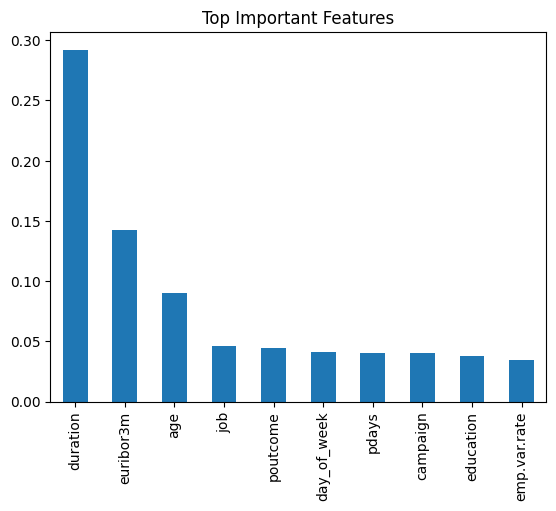

In [24]:
importances = rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()